# Lecture 11: ARIMA Models

*DASCI 270 - Time Series Analysis*

*Prepared by Sebastian C. Ibañez, PhD*

*Based on [FPPY Chapter 9](https://otexts.com/fpppy/nbs/09-arima.html)*

`Prediction is difficult- particularly when it involves the future. -Mark Twain`

In [17]:
%%capture
!pip install statsforecast
!pip install utilsforecast

!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/PBS_unparsed.csv' -P ./data/
!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/aus_retail.csv' -P ./data/
!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/global_economy.csv' -P ./data/
!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/us_employment.csv' -P ./data/
!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/aus_economy.csv' -P ./data/
!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/aus_production.csv' -P ./data/

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
})

pd.set_option("display.precision", 4)
np.set_printoptions(suppress=True)

## Stationarity

A **stationary** time series is one whose statistical properties does not depend on the time at which the series is observed.

More precisely, we say that $\{y_t\}$ is a stationary time series if the joint distribution of $(y_t, y_{t+1}, \ldots, y_{t+s})$ does not depend on $t$, for all $s$.

More intuitively:

- Time series that exhibit *trends* or *seasonality* are NOT stationary.


- Time series that exhibit changes in *variance* (also called *dynamic volatility*) or abrupt changes in *level* or *mean* are NOT stationary.

There is also the concept of **weak stationarity**, which refers to time series whose mean and autocovariance do not vary with respect to time (with finite variance at any point).

### Trend

A **trend** occurs when there is a long-term increase or decrease in the data.

It does not necessarily have to be linear in nature.

### Seasonality

**Seasonality** is characterized by periodicity in the data that is tied to the calendar or season (e.g. month-of-the-year, day-of-the-week, hour-of-the-day).

It is always of a fixed and known period.

### Cycles

Sometimes, cyclic behavior can sometimes be mistaken for seasonality.

**Cycles** are not of a fixed length (the peaks and troughs do not occur at regular intervals).

A time series with cyclic behavior (but with no trend and seasonality) can be stationary.

### Examples

![Figure from FPP3.](https://otexts.com/fpppy/nbs/09-arima_files/figure-html/fig-stationary-output-1.png)

Which of these time series are stationary?

## Differencing

One way to make a time series stationary is to use **differencing**,

$$y_t' = y_t - y_{t-1}$$

where $y_t'$ is a *new* time series.

Note that the differenced series will have only $T-1$ values, since you can't calculate $y'_1$.

Relatedly, the method used above is sometimes referred to as **first differencing**.

### Seasonal Differencing

In addition, we can also perform **seasonal differencing** (also called **lag-$m$ differencing**), a generalization of the first-order differencing shown above,

$$y_t' = y_t - y_{t-m}$$

where $m$ is the number of seasons.

### Notes on Differencing and Transformations

- Sometimes it is necessary to take several first differences to get a stationary series.
- Sometimes it is necessary to take both a seasonal diference and a first difference to get a stationary series.
- The order in which you apply seasonal and first differences doesn't matter.
- Applying more differences than required can sometimes induce false dynamics/autocorrelations. So minimize the number of differences performed!
- Applying a **log transform** can sometimes help stabilize the variance of a time series.

### Example: Australian drug sales

In [21]:
df_pbs = pd.read_csv("data/PBS_unparsed.csv", parse_dates=["Month"])
df_pbs = df_pbs.rename(columns={"Month": "ds"})
df_pbs = df_pbs.query("ATC2 == 'H02'").reset_index(drop=True) # Corticosteroid drug
df_pbs = df_pbs.groupby(["ds"])["Cost"].sum().reset_index()
df_pbs = df_pbs.rename(columns={"Cost": "Sales"})

# log transform
df_pbs["Log sales"] = np.log(df_pbs["Sales"])

# seasonal diff
df_pbs["Annual change in log sales"] = df_pbs["Log sales"].diff(periods=12)

# double seasonal diff
df_pbs["Doubly differenced log sales"] = df_pbs["Annual change in log sales"].diff(periods=12)
df_pbs

,ds,Sales,Log sales,Annual change in log sales,Doubly differenced log sales
0,1991-07-01,429795.0,12.9711,NaN,NaN
1,1991-08-01,400906.0,12.9015,NaN,NaN
2,1991-09-01,432159.0,12.9765,NaN,NaN
3,1991-10-01,492543.0,13.1073,NaN,NaN
4,1991-11-01,502369.0,13.1271,NaN,NaN
...,...,...,...,...,...
199,2008-02-01,761822.0,13.5435,0.2425,0.2246
200,2008-03-01,649435.0,13.3839,-0.0812,-0.0776
201,2008-04-01,827887.0,13.6266,0.3878,0.5176
202,2008-05-01,816255.0,13.6125,0.0910,0.1711


In [22]:
# convert to long format
df_pbs = df_pbs.set_index(["ds"]).stack().reset_index()
df_pbs = df_pbs.rename(columns={"level_1": "unique_id", 0: "y"})
df_pbs = df_pbs.sort_values(by=["unique_id", "ds"], ascending=[False, True]).reset_index(drop=True)
df_pbs

,ds,unique_id,y
0,1991-07-01,Sales,429795.0000
1,1991-08-01,Sales,400906.0000
2,1991-09-01,Sales,432159.0000
3,1991-10-01,Sales,492543.0000
4,1991-11-01,Sales,502369.0000
...,...,...,...
775,2008-02-01,Annual change in log sales,0.2425
776,2008-03-01,Annual change in log sales,-0.0812
777,2008-04-01,Annual change in log sales,0.3878
778,2008-05-01,Annual change in log sales,0.0910


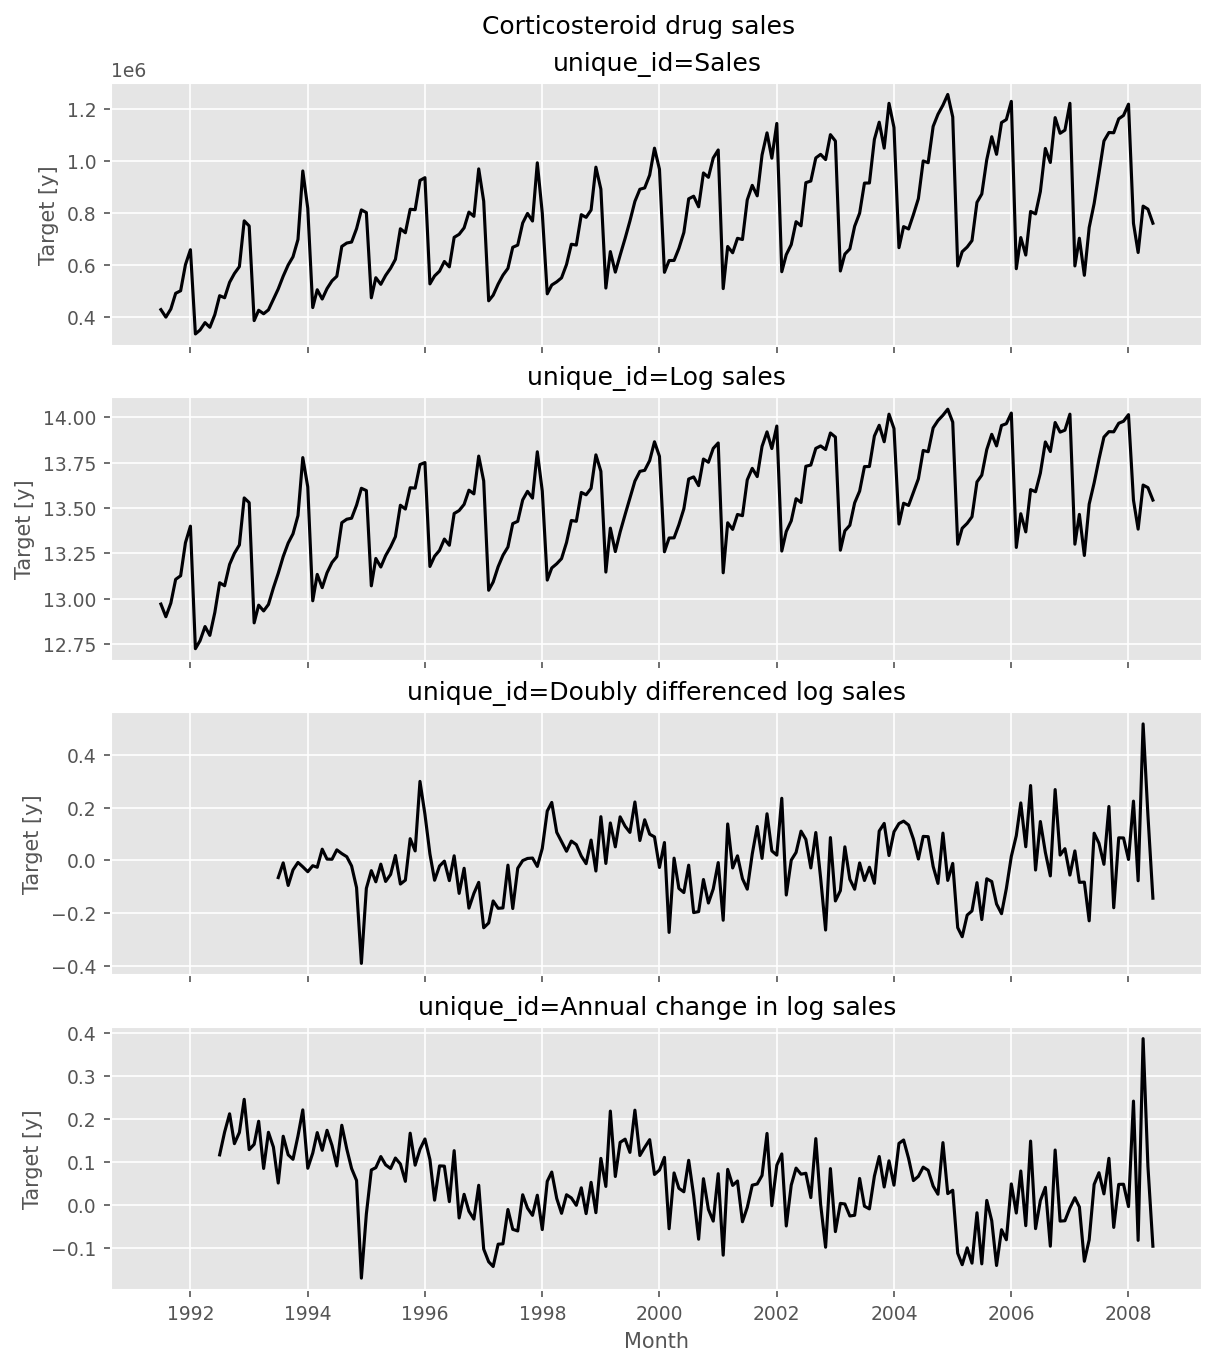

In [23]:
from utilsforecast.plotting import plot_series as plot_series_utils

_, axes = plt.subplots(nrows=4, ncols=1, figsize=(8, 9), sharex=True)
fig = plot_series_utils(df_pbs, ax=axes, palette='inferno')
for ax in fig.axes:
    ax.tick_params(axis='both')
    if ax.get_legend():
        ax.get_legend().remove()
    for label in ax.get_xticklabels():
        label.set_rotation(0)
fig.legends = []
ax.set_xlabel("Month")
fig.suptitle("Corticosteroid drug sales", x=0.525)
fig

## Tests of Stationarity

To check for stationarity more formally, we can use a hypothesis test.

The two most commonly used tests for stationarity are **Augmented Dickey-Fuller** (ADF) and **Kwiatkowski-Phillips-Schmidt-Shin** (KPSS).

In the ADF test, the null hypothesis is that the series is non-stationary.

In the KPSS test, the null hypothesis is that the series is stationary.

These tests specifically test for *trend stationarity*, meaning that it is best to remove the seasonality first to avoid false positives/negatives.

Therefore:

1. For ADF, low p-value implies series is probably stationary.

2. For KPSS, high p-value implies series is probably stationary.

*Note: The KPSS test will throw a warning if the p-value > 0.1 (probably stationary) or if the p-value < 0.01 (probably NOT stationary).*

In [24]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

def adf_test(ts):
    res = adfuller(ts)
    print('ADF = %f' % res[0])
    print('p-value = %f' % res[1])
    print('Critical Values:')
    for k, v in res[4].items():
        print('\t%s: %.3f' % (k, v))

def kpss_test(ts):
    res = kpss(ts, nlags='auto')
    print('KPSS = %f' % res[0])
    print('p-value = %f' % res[1])
    print('Critical Values:')
    for k, v in res[3].items():
        print('\t%s: %.3f' % (k, v))

print('Tests for Log Sales:')
adf_test(df_pbs[df_pbs['unique_id'] == 'Log sales']['y'])
print()
kpss_test(df_pbs[df_pbs['unique_id'] == 'Log sales']['y'])

Tests for Log Sales:
ADF = -2.231386
p-value = 0.195052
Critical Values:
	1%: -3.466
	5%: -2.877
	10%: -2.575

KPSS = 1.954653
p-value = 0.010000
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739


/var/folders/9y/vgkg6w9144v1vtff9_5ft2fw0000gn/T/ipykernel_35643/4179157803.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  res = kpss(ts, nlags='auto')


In [25]:
print('Tests for sea diff:')
adf_test(df_pbs[df_pbs['unique_id'] == 'Annual change in log sales']['y'])
print()
kpss_test(df_pbs[df_pbs['unique_id'] == 'Annual change in log sales']['y'])

Tests for sea diff:
ADF = -2.819727
p-value = 0.055511
Critical Values:
	1%: -3.468
	5%: -2.878
	10%: -2.576

KPSS = 0.575705
p-value = 0.024845
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739


In [26]:
print('Tests for double sea diff:')
adf_test(df_pbs[df_pbs['unique_id'] == 'Doubly differenced log sales']['y'])
print()
kpss_test(df_pbs[df_pbs['unique_id'] == 'Doubly differenced log sales']['y'])

Tests for double sea diff:
ADF = -3.534573
p-value = 0.007142
Critical Values:
	1%: -3.471
	5%: -2.879
	10%: -2.576

KPSS = 0.115221
p-value = 0.100000
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739


/var/folders/9y/vgkg6w9144v1vtff9_5ft2fw0000gn/T/ipykernel_35643/4179157803.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  res = kpss(ts, nlags='auto')


## ARIMA

ARIMA stands for **autoregressive integrated moving average** and has three components:

1. The autoregressive (AR) component with order $p$ is defined as,

\begin{align*}
    y_t &= c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \varepsilon_t \\
    &= c + \sum_{i=1}^{p} \phi_i y_{t-i} + \varepsilon_t
\end{align*}

2. The moving average (MA) component with order $q$ is defined as,

\begin{align*}
    y_t &= c + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \cdots + \theta_q \varepsilon_{t-q} + \varepsilon_t \\
    &= c + \sum_{i=1}^{q} \theta_i \varepsilon_{t-i} + \varepsilon_t
\end{align*}

3. The order of integration (I) $d$ is the number of first differences required before the series becomes stationary.

Thus, ARIMA models are defined by three parameters $(p,d,q)$ and can be written as,

\begin{align*}
    y_t' &= c + \sum_{i=1}^{p} \phi_i y_{t-i}' + \sum_{i=1}^{q} \theta_i \varepsilon_{t-i} + \varepsilon_t
\end{align*}

where $y_t'$ is the $d$-differenced series.

The predictors in a ARIMA model are the lagged values of $y_t$ and the lagged errors.

### Special cases of the ARIMA model

| Special case | ARIMA(p, d, q) |
|---|---|
| White noise | ARIMA(0,0,0) with no constant|
| Random walk | ARIMA(0,1,0) with no constant|
| Random walk with drift | ARIMA(0,1,0) with a constant|
| Autoregression | ARIMA(p,0,0) |
| Moving average | ARIMA(0,0,q) |

### Example: Egyptian exports

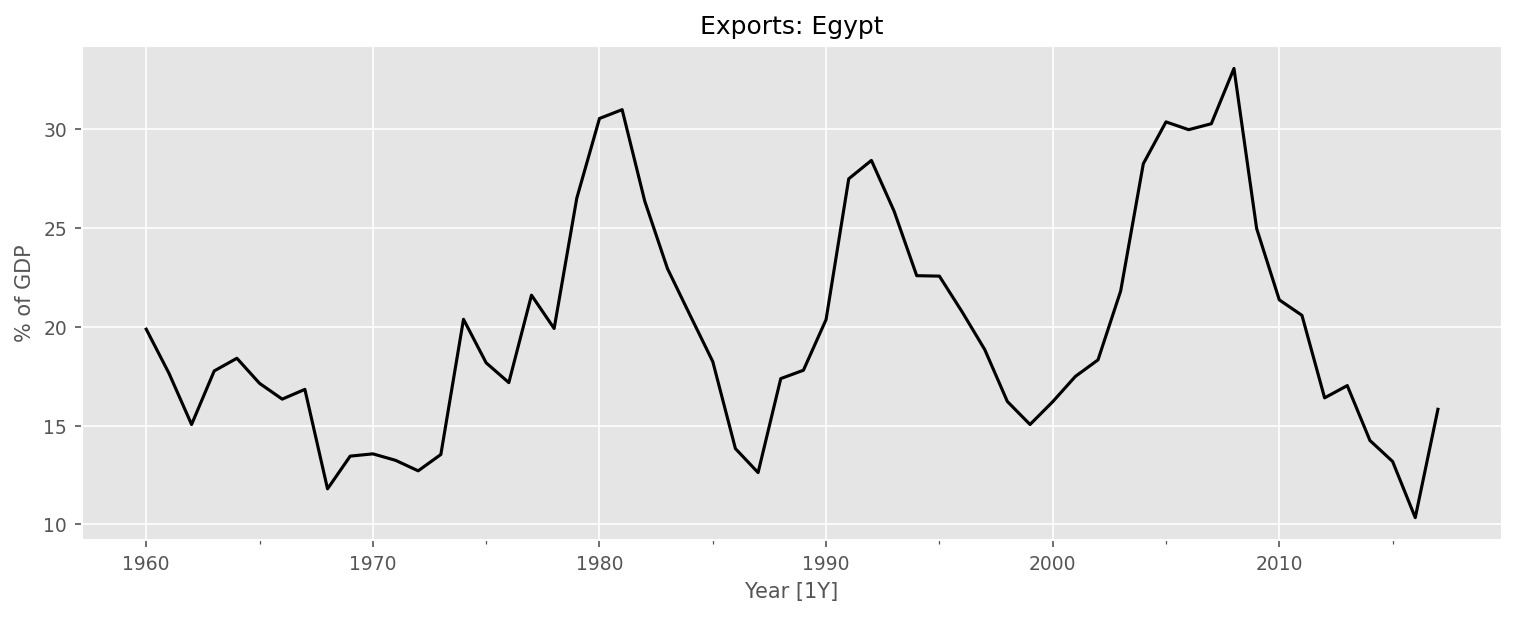

,unique_id,Code,ds,GDP,Growth,CPI,Imports,y,Population
0,"Egypt, Arab Rep.",EGY,1960-01-01,NaN,NaN,1.2087,21.8255,19.8662,2.6997e+07
1,"Egypt, Arab Rep.",EGY,1961-01-01,NaN,5.1611,1.2171,19.7419,17.6463,2.7745e+07
2,"Egypt, Arab Rep.",EGY,1962-01-01,NaN,3.8756,1.1806,19.5185,15.0524,2.8506e+07
3,"Egypt, Arab Rep.",EGY,1963-01-01,NaN,10.5181,1.1894,23.5869,17.7589,2.9281e+07
4,"Egypt, Arab Rep.",EGY,1964-01-01,NaN,11.5076,1.2329,24.8742,18.3980,3.0071e+07


In [27]:
df_global = pd.read_csv("data/global_economy.csv", parse_dates=[2])
df_global = df_global.rename(columns={"Exports": "y"})
df_egypt = df_global.query("Code == 'EGY'").reset_index(drop=True)

fig, ax = plt.subplots()
df_egypt.plot(ax=ax, x='ds', y='y', color='black', legend=False)
ax.set_title("Exports: Egypt")
ax.set_xlabel("Year [1Y]")
ax.set_ylabel("% of GDP")
plt.autoscale()
plt.show()

df_egypt.head()

In [28]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.arima import ARIMASummary
from copy import deepcopy

models = [AutoARIMA(allowmean=True)]

sf = StatsForecast(models=models, freq="YE", n_jobs=-1)

sf.fit(df=df_egypt[["ds", "y", "unique_id"]])

print(ARIMASummary(sf.fitted_[0, 0].model_))
coefs = deepcopy(sf.fitted_[0, 0].model_['coef'])
coefs["mean"] = coefs.pop("intercept")
print(f"Coefficients: {coefs}")
print(f"sigma^2     : {sf.fitted_[0, 0].model_['sigma2']:.2f}")
print(f"loglik      : {sf.fitted_[0, 0].model_['loglik']:.2f}")
print(f"aic         : {sf.fitted_[0, 0].model_['aic']:.2f}")
print(f"aicc        : {sf.fitted_[0, 0].model_['aicc']:.2f}")
print(f"bic         : {sf.fitted_[0, 0].model_['bic']:.2f}")

ARIMA(2,0,1) with non-zero mean
Coefficients: {'ar1': 1.67642819286411, 'ar2': -0.8034081751182518, 'ma1': -0.6896288023651153, 'mean': 20.17901830549594}
sigma^2     : 8.05
loglik      : -141.57
aic         : 293.13
aicc        : 294.29
bic         : 303.43


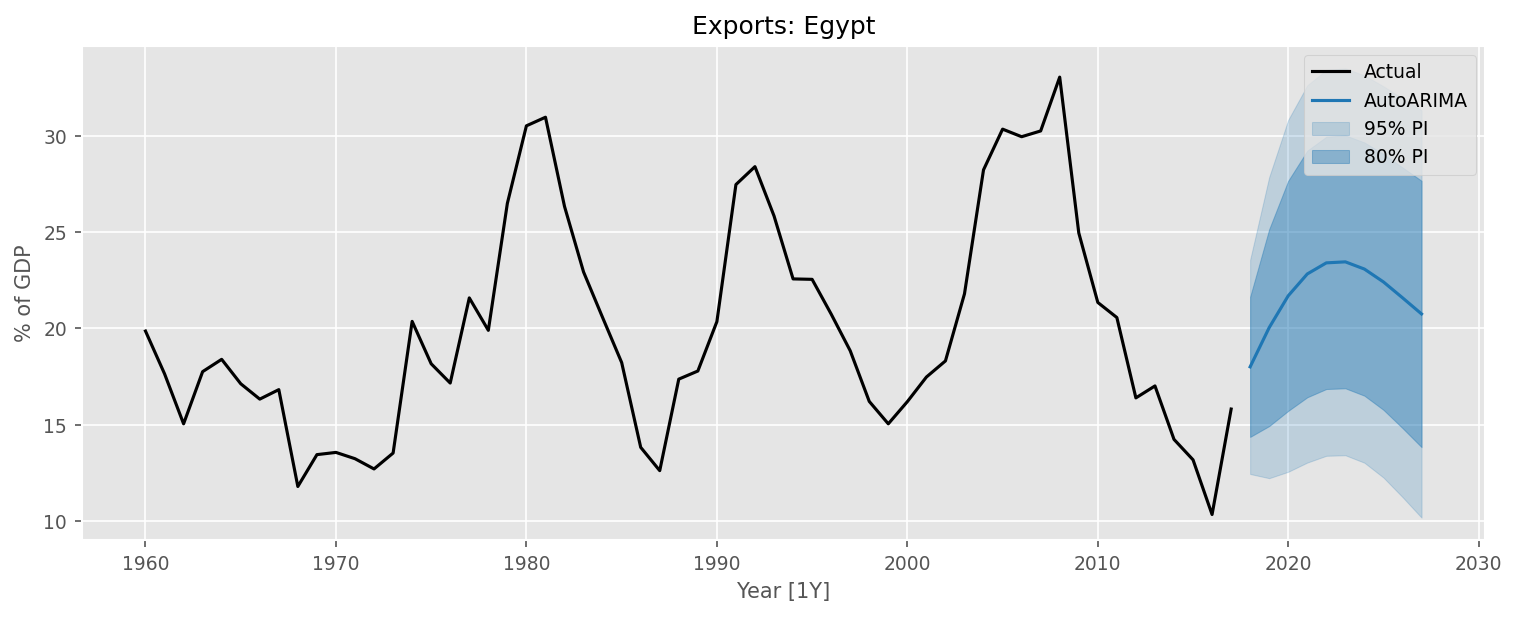

In [29]:
df_f = sf.predict(h=10, level=[80, 95])

fig, ax = plt.subplots()
plt.plot(df_egypt["ds"], df_egypt['y'], color='black')
plt.plot(df_f["ds"], df_f['AutoARIMA'], color='tab:blue')
plt.fill_between(df_f["ds"], df_f['AutoARIMA-lo-95'], df_f['AutoARIMA-hi-95'], color='tab:blue', alpha = 0.2)
plt.fill_between(df_f["ds"], df_f['AutoARIMA-lo-80'], df_f['AutoARIMA-hi-80'], color='tab:blue', alpha = 0.4)
ax.set_title("Exports: Egypt")
ax.set_xlabel("Year [1Y]")
ax.set_ylabel("% of GDP")
plt.legend(['Actual', 'AutoARIMA', '95% PI', '80% PI'])
plt.autoscale()
plt.show()

### AutoARIMA

The `AutoARIMA()` model uses a variation of the Hyndman-Khandakar algorithm (Hyndman & Khandakar, 2008), which combines unit root tests, minimisation of the AICc and MLE to obtain an ARIMA model.

The original algorithm is as follows:

![](https://otexts.com/fpppy/nbs/09-arima_files/figure-html/hkalgorithm-output-1.png)

The figure below illustrates diagrammatically how the Hyndman-Khandakar algorithm traverses the space of the ARMA orders, through an example. You can read about it more in detail [here](https://otexts.com/fpppy/nbs/09-arima.html#how-does-autoarima-work).

![](https://otexts.com/fpppy/nbs/09-arima_files/figure-html/fig-armagridsearch-output-1.png)



### AutoETS

Simiarly, the `AutoETS()` model selects the best ETS model using an information criterion (e.g. [AICc](https://otexts.com/fpppy/nbs/07-regression.html#corrected-akaikes-information-criterion)). The actual algorithm implemented in `statsforecast` can be viewed [here](https://github.com/Nixtla/statsforecast/blob/main/python/statsforecast/ets.py#L872C5-L872C9).

## Seasonal ARIMA

The standard ARIMA model can also be extended to include additional terms to account for seasonality in the data. The notation for its parameters are written as follows:

\begin{align*}
  \text{ARIMA}(p,d,q)(P,D,Q)_{m}
\end{align*}

where $m$ is the seasonal period.

### Example: Monthly US leisure and hospitality employment

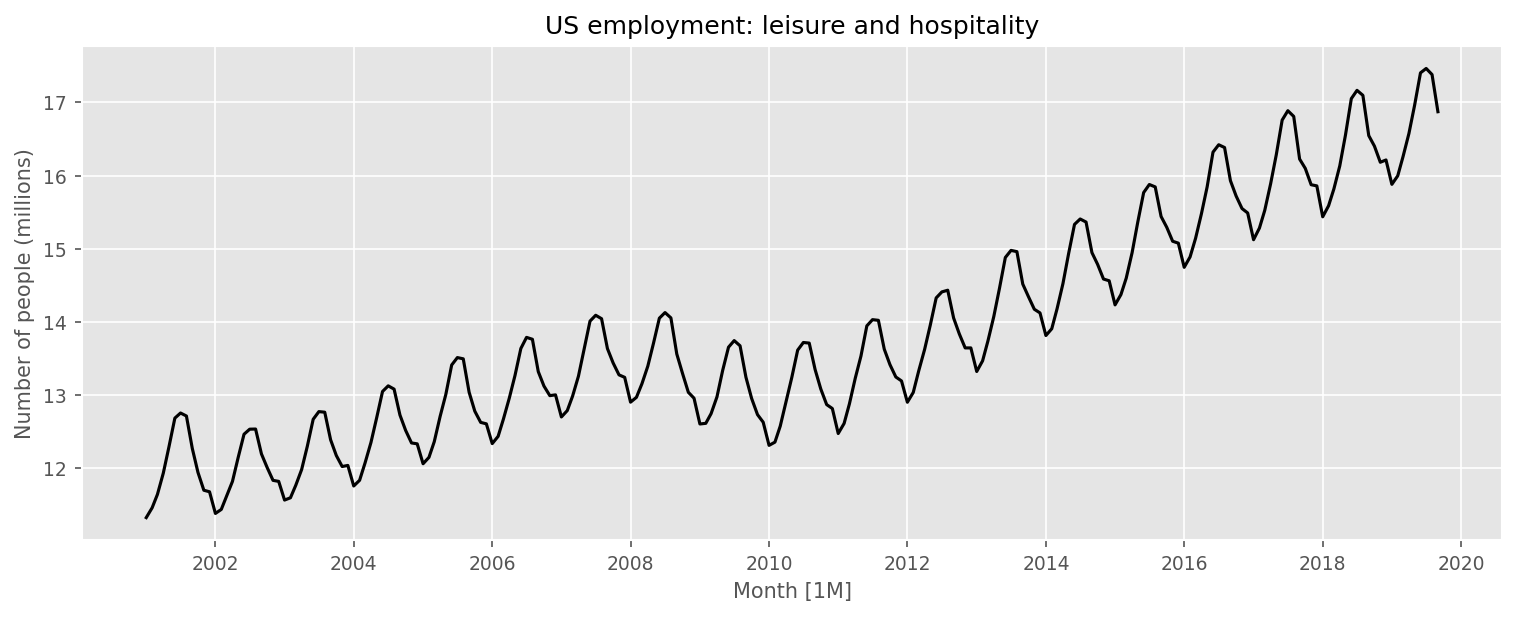

In [30]:
df_employ = pd.read_csv("data/us_employment.csv", parse_dates=["ds"])

df_leisure = df_employ.query("unique_id == 'Leisure and Hospitality' and ds.dt.year > 2000").reset_index(drop=True)
df_leisure["y"] /= 1000

fig, ax = plt.subplots()
plt.plot(df_leisure["ds"], df_leisure['y'], color='black')
plt.title("US employment: leisure and hospitality")
plt.xlabel("Month [1M]")
plt.ylabel("Number of people (millions)")
plt.autoscale()
plt.show()

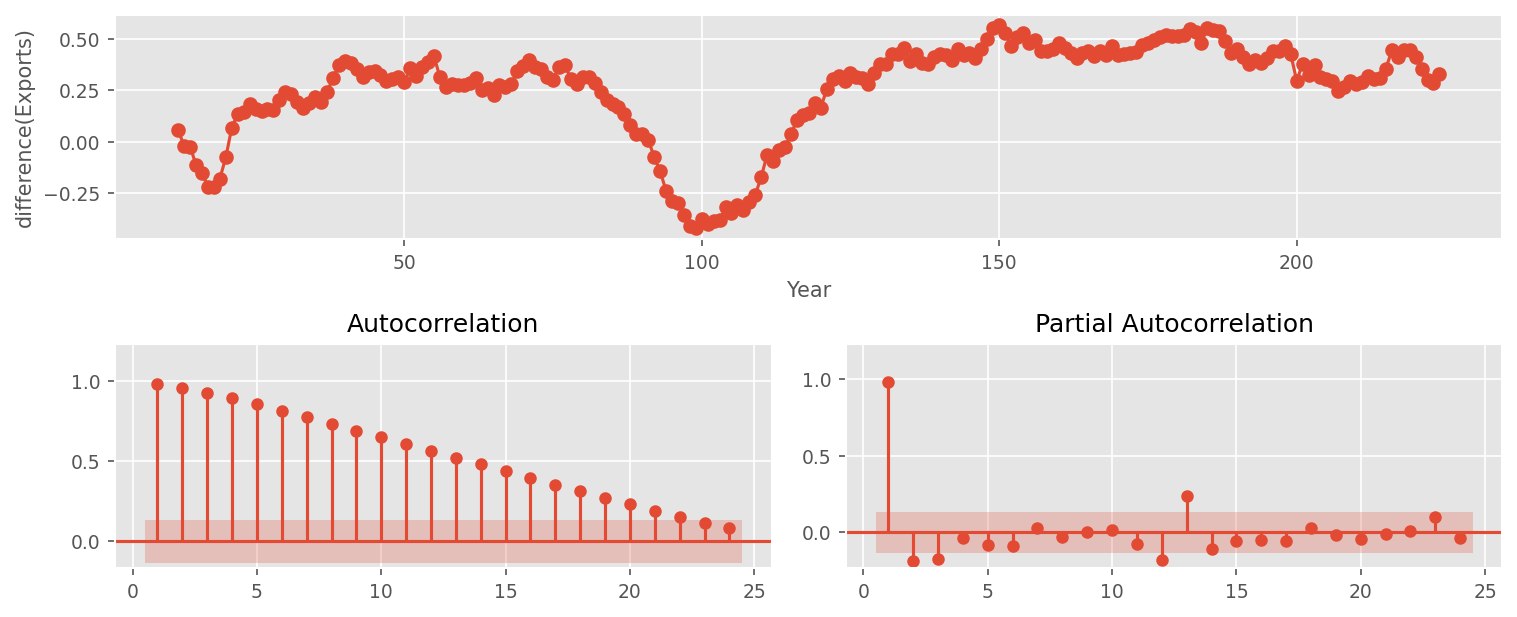

In [31]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

leisure_difference = df_leisure["y"].diff(12)[12:] # sea diff

fig = plt.figure()

gs = fig.add_gridspec(2, 2)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

ax1.plot(leisure_difference, marker="o")
ax1.set_ylabel("difference(Exports)")
ax1.set_xlabel("Year")

plot_acf(leisure_difference, ax2, zero=False, lags=24, bartlett_confint=False,
         auto_ylims=True)
plot_pacf(leisure_difference, ax3, zero=False, lags=24,
          auto_ylims=True)
plt.show()

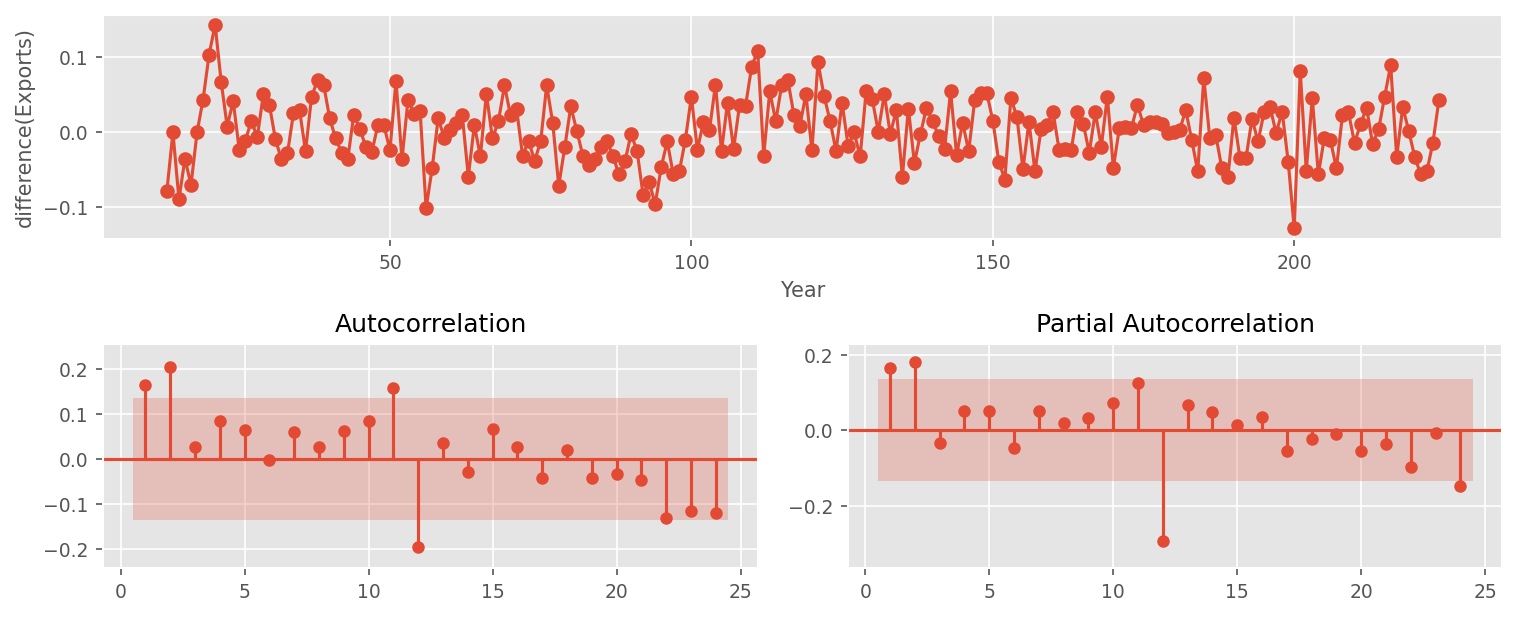

In [32]:
leisure_double_difference = leisure_difference.diff()[1:] # diff 1

fig = plt.figure()

gs = fig.add_gridspec(2, 2)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

ax1.plot(leisure_double_difference, marker="o")
ax1.set_ylabel("difference(Exports)")
ax1.set_xlabel("Year")

plot_acf(leisure_double_difference, ax2, zero=False, lags=24,
         bartlett_confint=False,
         auto_ylims=True)
plot_pacf(leisure_double_difference, ax3, zero=False, lags=24,
          auto_ylims=True)
plt.show()

In [33]:
from statsforecast.models import ARIMA,AutoARIMA

models = [
    AutoARIMA(alias="auto", season_length=12),
    AutoARIMA(stepwise=False, approximation=False, alias="auto-brute", season_length=12), # do brute force grid search, also no approximations
]

sf = StatsForecast(models=models, freq="MS", n_jobs=-1)

sf.fit(df=df_leisure[["ds", "y", "unique_id"]])

summaries = []
for model in sf.fitted_[0]:
    summary_model = {
        "model": model,
        "Orders": ARIMASummary(model.model_),
        "sigma2": model.model_["sigma2"],
        "loglik": model.model_["loglik"],
        "aic": model.model_["aic"],
        "aicc": model.model_["aicc"],
        "bic": model.model_["bic"],
    }
    summaries.append(summary_model)

pd.DataFrame(sorted(summaries, key=lambda d: d["aicc"]))

,model,Orders,sigma2,loglik,aic,aicc,bic
0,auto-brute,"ARIMA(2,1,0)(0,1,2)[12]",0.0014,394.4699,-778.9399,-778.6486,-762.1569
1,auto,"ARIMA(0,1,2)(0,1,2)[12]",0.0014,394.1861,-778.3723,-778.0810,-761.5893


In [34]:
df_f = sf.forecast(df=df_leisure[["ds", "y", "unique_id"]], h=36, fitted=True, level=[80, 95])
df_f.head()

,unique_id,ds,auto,auto-lo-95,auto-lo-80,auto-hi-80,auto-hi-95,auto-brute,auto-brute-lo-95,auto-brute-lo-80,auto-brute-hi-80,auto-brute-hi-95
0,Leisure and Hospitality,2019-10-01,16.7127,16.6387,16.6643,16.7612,16.7868,16.7100,16.6360,16.6616,16.7583,16.7840
1,Leisure and Hospitality,2019-11-01,16.5079,16.3918,16.4320,16.5838,16.6240,16.5019,16.3864,16.4263,16.5774,16.6174
2,Leisure and Hospitality,2019-12-01,16.5106,16.3540,16.4082,16.6131,16.6673,16.5035,16.3472,16.4013,16.6057,16.6598
3,Leisure and Hospitality,2020-01-01,16.1700,15.9813,16.0466,16.2933,16.3586,16.1607,15.9689,16.0353,16.2861,16.3525
4,Leisure and Hospitality,2020-02-01,16.2964,16.0805,16.1552,16.4376,16.5124,16.2877,16.0638,16.1413,16.4341,16.5117


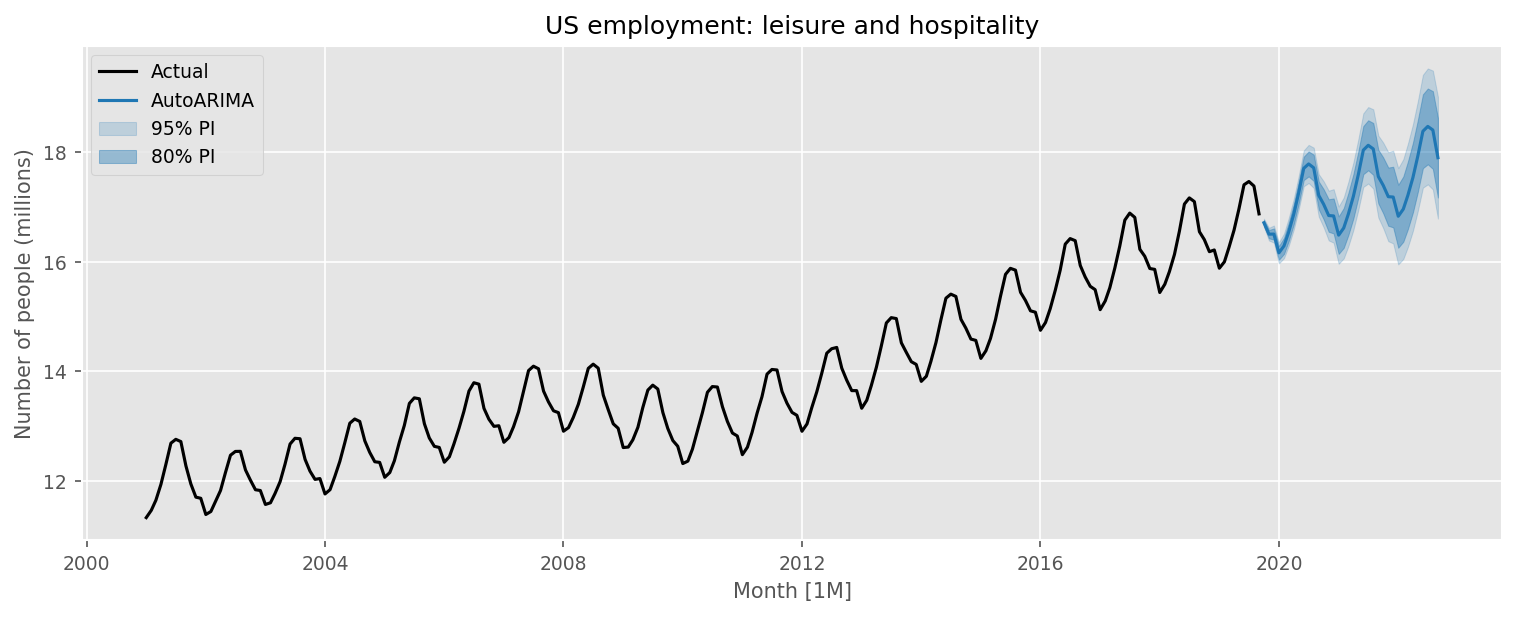

In [35]:
fig, ax = plt.subplots()
plt.plot(df_leisure["ds"], df_leisure['y'], color='black')
plt.plot(df_f["ds"], df_f['auto-brute'], color='tab:blue')
plt.fill_between(df_f["ds"], df_f['auto-brute-lo-95'], df_f['auto-brute-hi-95'], color='tab:blue', alpha = 0.2)
plt.fill_between(df_f["ds"], df_f['auto-brute-lo-80'], df_f['auto-brute-hi-80'], color='tab:blue', alpha = 0.4)
plt.title("US employment: leisure and hospitality")
plt.xlabel("Month [1M]")
plt.ylabel("Number of people (millions)")
plt.legend(['Actual', 'AutoARIMA', '95% PI', '80% PI'])
plt.autoscale()
plt.show()

## ARIMA vs ETS

It is a commonly held myth that ARIMA models are more general than exponential smoothing.

While linear exponential smoothing models are all special cases of ARIMA models, the non-linear exponential smoothing models have no equivalent ARIMA counterparts.

On the other hand, there are also many ARIMA models that have no exponential smoothing counterparts.

In particular, all ETS models are non-stationary, while some ARIMA models are stationary.

![](https://otexts.com/fpppy/nbs/09-arima_files/figure-html/fig-venn-output-1.png)

Below are the equivalences between certain ETS and ARIMA models:

![](https://otexts.com/fpppy/nbs/09-arima_files/figure-html/fig-arimaets-output-1.png)


### Example: Quarterly cement production in Australia

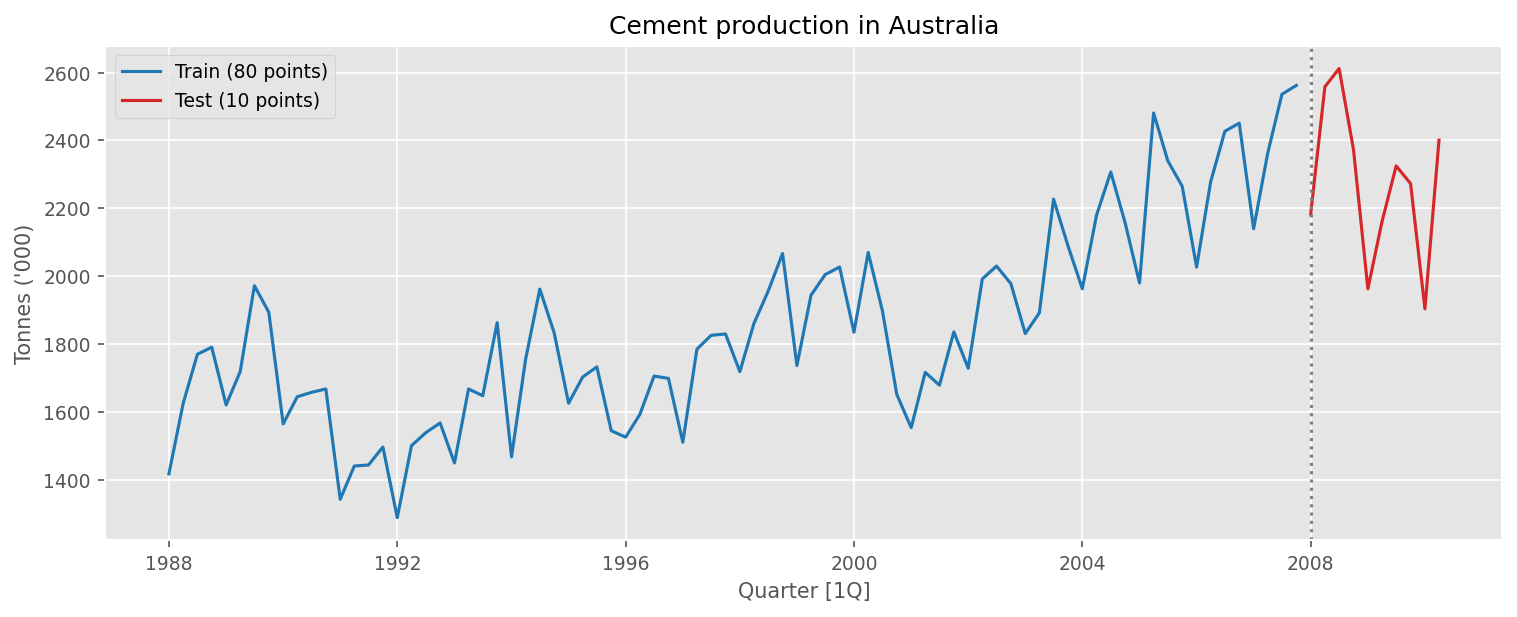

In [36]:
df_prod = pd.read_csv("data/aus_production.csv", parse_dates=["ds"])
df_cement = df_prod.query("ds.dt.year >= 1988")[["ds", "Cement"]]
df_cement.insert(0, "unique_id", "Cement")
df_cement.rename(columns={"Cement": "y"}, inplace=True)

df_train = df_cement.query("ds.dt.year < 2008").reset_index(drop=True) # will CV on this!
df_test = df_cement.query("ds.dt.year >= 2008").reset_index(drop=True) # final test

fig, ax = plt.subplots()
plt.plot(df_train["ds"], df_train['y'], color='tab:blue')
plt.plot(df_test["ds"], df_test['y'], color='tab:red')
plt.title("Cement production in Australia")
plt.xlabel("Quarter [1Q]")
plt.ylabel("Tonnes ('000)")
plt.axvline(x=df_test['ds'].iloc[0], color='grey', linestyle='dotted')
plt.legend([f'Train ({len(df_train)} points)', f'Test ({len(df_test)} points)'])
plt.autoscale()
plt.show()

In [40]:
from functools import partial
from statsforecast.models import AutoETS
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape as _mape, mase, rmsse

sf = StatsForecast(models=[AutoARIMA(season_length=4), AutoETS(season_length=4)], freq="QS", n_jobs=-1)

h = len(df_test)
df_f = sf.cross_validation(h=h, df=df_train, step_size=1, test_size=h*2) # Use 20 data points for CV
df_f = df_f.drop(['cutoff'], axis=1)

def mape(df, models, id_col = "unique_id", target_col = "y"):
    df_mape = _mape(df, models, id_col=id_col, target_col=target_col)
    df_mape.loc[:, df_mape.select_dtypes(include='number').columns] *= 100
    return df_mape

df_eval = evaluate(df_f, metrics=[mae, rmse, mape, partial(mase, seasonality=4), partial(rmsse, seasonality=4)], train_df=df_train)
df_eval.set_index('metric').T.drop('unique_id').sort_values(by='mae')

metric,mae,rmse,mape,mase,rmsse
AutoETS,160.9519,196.5001,7.0648,1.0996,1.1429
AutoARIMA,229.3825,269.5767,10.0812,1.5672,1.5679


Looks like AutoETS is the best model when cross-validated on the train set.

Let's look at how the two models perform on the test set.

In [41]:
sf = StatsForecast(models=[AutoARIMA(season_length=4), AutoETS(season_length=4)], freq="QS", n_jobs=-1)

df_f = sf.forecast(h=h, df=df_train, level=[80, 95])

df_f['y'] = df_test['y'].values # append ground truth "y"

df_eval = evaluate(df_f, metrics=[mae, rmse, mape, partial(mase, seasonality=4), partial(rmsse, seasonality=4)], train_df=df_train) # mase uses snaive as scaler
df_eval.set_index('metric').T.drop('unique_id').sort_values(by='mae')

metric,mae,rmse,mape,mase,rmsse
AutoARIMA,169.078,195.204,7.8685,1.1552,1.1353
AutoETS,191.1517,222.1804,8.8623,1.306,1.2922


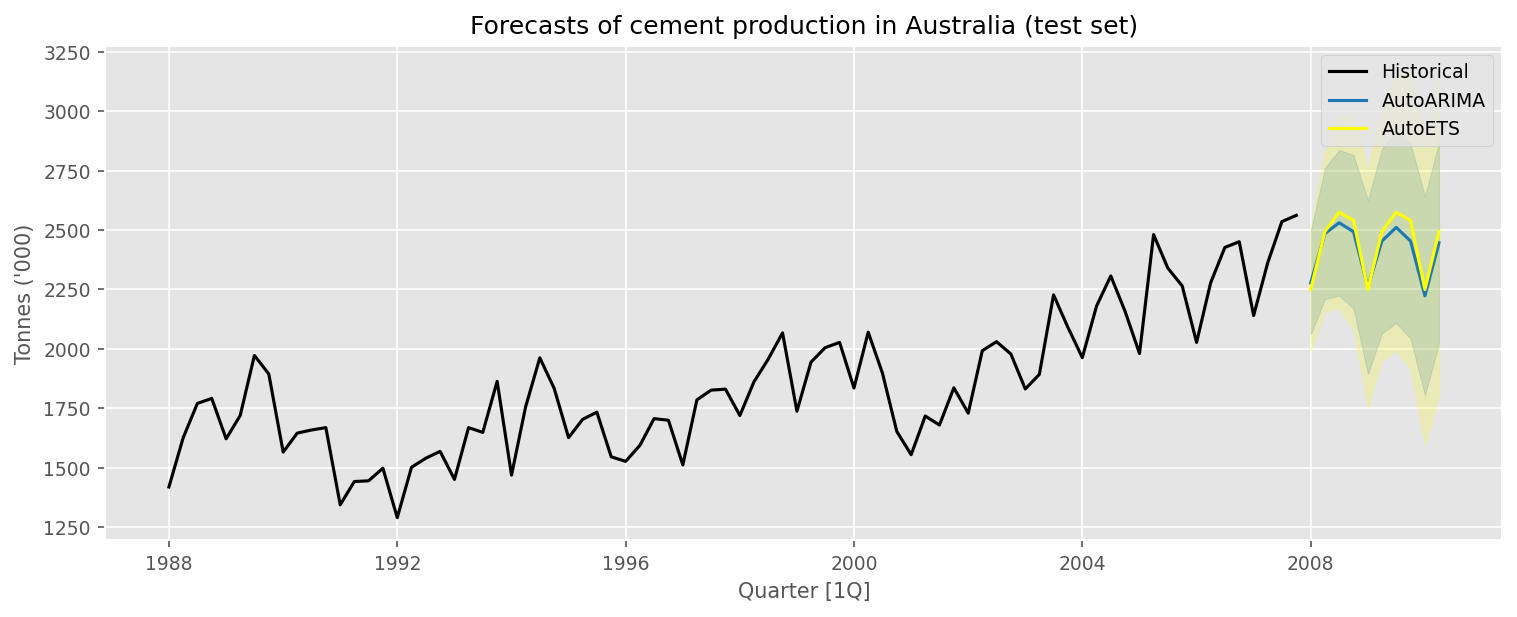

In [42]:
fig, ax = plt.subplots()
plt.plot(df_train["ds"], df_train['y'], color='black')
plt.plot(df_f["ds"], df_f['AutoARIMA'], color='tab:blue')
plt.plot(df_f["ds"], df_f['AutoETS'], color='yellow')
plt.fill_between(df_f["ds"], df_f['AutoARIMA-lo-95'], df_f['AutoARIMA-hi-95'], color='tab:blue', alpha = 0.2)
plt.fill_between(df_f["ds"], df_f['AutoETS-lo-95'], df_f['AutoETS-hi-95'], color='yellow', alpha = 0.2)
plt.title("Forecasts of cement production in Australia (test set)")
plt.xlabel("Quarter [1Q]")
plt.ylabel("Tonnes ('000)")
plt.legend(['Historical', 'AutoARIMA', 'AutoETS'])
plt.autoscale()
plt.show()

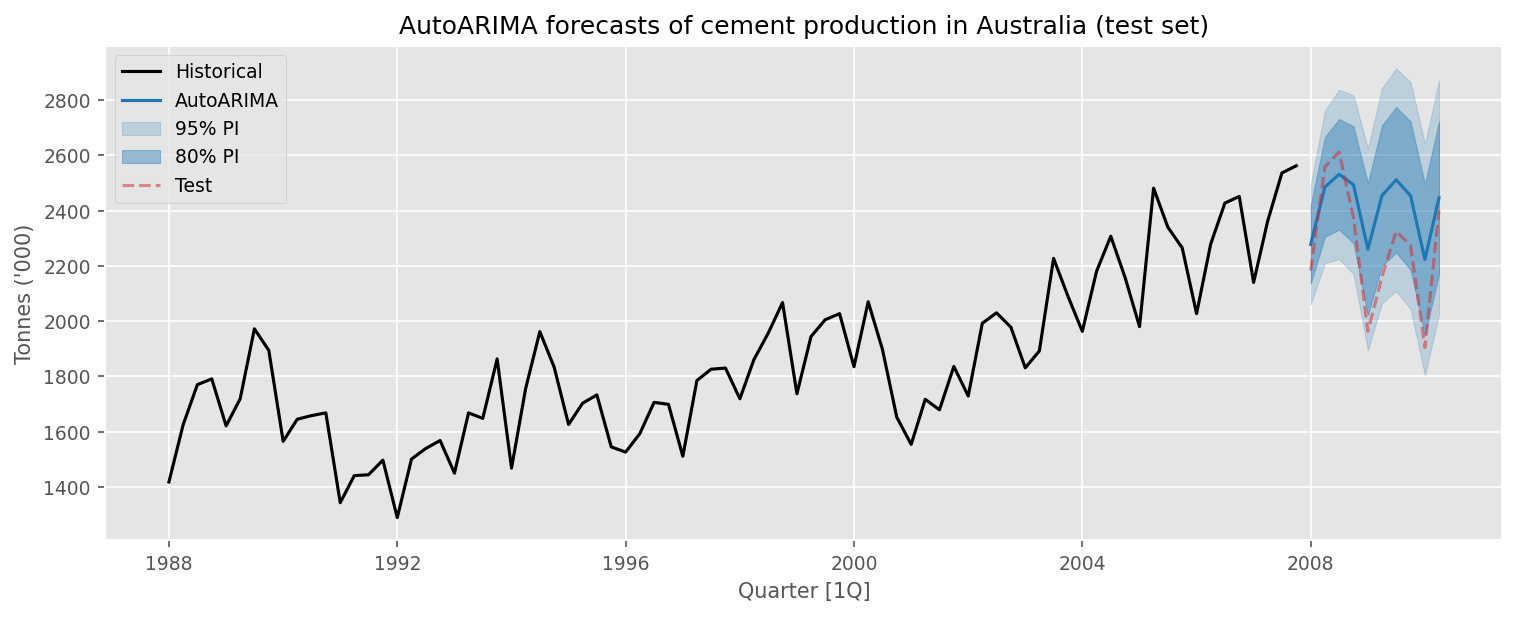

In [43]:
fig, ax = plt.subplots()
plt.plot(df_train["ds"], df_train['y'], color='black')
plt.plot(df_f["ds"], df_f['AutoARIMA'], color='tab:blue')
plt.fill_between(df_f["ds"], df_f['AutoARIMA-lo-95'], df_f['AutoARIMA-hi-95'], color='tab:blue', alpha = 0.2)
plt.fill_between(df_f["ds"], df_f['AutoARIMA-lo-80'], df_f['AutoARIMA-hi-80'], color='tab:blue', alpha = 0.4)
plt.plot(df_test["ds"], df_test['y'], color='tab:red', alpha=0.5, linestyle='--')
plt.title("AutoARIMA forecasts of cement production in Australia (test set)")
plt.xlabel("Quarter [1Q]")
plt.ylabel("Tonnes ('000)")
plt.legend(['Historical', 'AutoARIMA', '95% PI', '80% PI', 'Test'])
plt.autoscale()
plt.show()

In [44]:
sf = StatsForecast(models=[AutoARIMA(season_length=4), AutoETS(season_length=4)], freq="QS", n_jobs=-1)

h = len(df_test)
df_f = sf.cross_validation(h=h, df=df_cement, step_size=1, test_size=h*3) # CV on full dataset!
df_f = df_f.drop(['cutoff'], axis=1)

def mape(df, models, id_col = "unique_id", target_col = "y"):
    df_mape = _mape(df, models, id_col=id_col, target_col=target_col)
    df_mape.loc[:, df_mape.select_dtypes(include='number').columns] *= 100
    return df_mape

df_eval = evaluate(df_f, metrics=[mae, rmse, mape, partial(mase, seasonality=4), partial(rmsse, seasonality=4)], train_df=df_cement)
df_eval.set_index('metric').T.drop('unique_id').sort_values(by='mae')

metric,mae,rmse,mape,mase,rmsse
AutoETS,151.2823,182.1231,6.5657,1.006,1.0299
AutoARIMA,198.0024,234.6045,8.5656,1.3166,1.3267
